# DATALAB MEF Maroc - UC-S1 - Etape 1
## Audit, preparation, deux ACP et typologie des pays

Notebook maitre : orchestre l'audit des donnees, le controle du dictionnaire
de variables, et les deux Analyses en Composantes Principales (profils
moyens par pays / trajectoires annuelles) avec typologie par classification.

Toutes les fonctions sont importees depuis `src/` (point d'entree modulaire
`run_etape1.py`). Ce notebook peut etre relance depuis un noyau propre :
il ne depend d'aucun etat externe autre que `configs/config.yaml`.

Convention de statut utilisee dans les commentaires : **implemente**,
**execute**, **evalue**, **valide**, **non concluant**, **bloque** (cf.
consigne de l'etape).


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import warnings
warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL.*",
    category=UserWarning,
)

import pandas as pd
from IPython.display import display, Image

from src import audit, clustering, io_utils, pca_profiles, pca_trajectories, plotting

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)


C:\Users\MR KITOHOU\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Configuration, environnement et chargement des donnees

In [2]:
cfg = io_utils.load_config()
logger = io_utils.setup_logging(cfg)
env = io_utils.log_environment(logger)
env


2026-09-14 01:44:49,175 [INFO] Environnement d'execution : {"python_version": "3.10.9", "python_executable": "C:\\Users\\MR KITOHOU\\anaconda3\\python.exe", "platform": "Windows-10-10.0.26200-SP0", "pandas": "2.3.3", "numpy": "1.26.4", "scikit_learn": "1.7.2", "scipy": "1.10.0", "matplotlib": "3.7.0", "statsmodels": "0.13.5"}


{'python_version': '3.10.9',
 'python_executable': 'C:\\Users\\MR KITOHOU\\anaconda3\\python.exe',
 'platform': 'Windows-10-10.0.26200-SP0',
 'pandas': '2.3.3',
 'numpy': '1.26.4',
 'scikit_learn': '1.7.2',
 'scipy': '1.10.0',
 'matplotlib': '3.7.0',
 'statsmodels': '0.13.5'}

In [3]:
work_df = io_utils.load_work_base(cfg, logger)
source_df = io_utils.load_source_base(cfg, logger)
registry = io_utils.load_variable_registry(cfg)

print("Fichier de travail :", work_df.shape)
print("Base source        :", source_df.shape)
work_df.head()


2026-09-14 01:44:49,198 [INFO] Fichier de travail charge : C:\Users\MR KITOHOU\Desktop\Work_DAVID_DG_Mohamed\Data_collection\base_MEF_1991_2024_9pays_28indicateurs.csv (shape=(306, 30), sha256=af4e19eec6159577)


2026-09-14 01:44:49,204 [INFO] Base source chargee : C:\Users\MR KITOHOU\Desktop\Work_DAVID_DG_Mohamed\Data_collection\data\base_B_revised_wide.csv (shape=(405, 32), sha256=083587b9b54e0b92)


Fichier de travail : (306, 30)
Base source        : (405, 32)


,country_iso3,year,BALANCE_COURANTE,CRDE,CROISSANCE_PIB,DETO,EMAG,EMIN,EMSE,EVNA,EXPO,EXPORT_MARCHANDISES_USD,FBCF,IDEE,IMPO,INFLATION_CPI,LFPRF,OUVERTURE_COM,POP_ACTIVE_TOTALE,RETO,SOBG,SOPR,TAAC,TACH,TAUX_EMPLOI_15P,UNFE,VAAG,VAIN,VASE,WSWF
0,CHL,1991,-0.255543,1.662900,7.756202,21.248734,16.722591,26.760737,56.516652,74.082,30.984879,8.942000e+09,20.749222,2.151844,26.522668,21.784412,31.873,57.507547,5120213.0,22.789961,1.541227,3.785388,56.670,5.23,50.416,5.700,9.162728,36.995475,46.137989,75.084478
1,CHL,1992,-2.056130,1.612446,11.501931,20.932553,15.831663,26.649239,57.519078,74.367,28.595070,1.000700e+10,23.498437,2.011436,26.946677,15.425806,33.205,55.541748,5322228.0,23.040160,2.107607,3.884624,57.931,4.35,51.887,5.340,9.089227,34.817031,47.591766,75.034777
2,CHL,1993,-5.111050,1.555755,6.685584,21.217570,14.487220,27.288794,58.223986,74.679,25.545056,9.199000e+09,26.218885,2.071295,27.368798,12.727767,34.088,52.913853,5480115.0,22.633006,1.415435,2.957829,58.680,4.49,52.349,5.115,7.929480,34.541908,48.691699,74.985294
3,CHL,1994,-2.762966,1.505947,5.076804,20.621123,14.157554,26.223050,59.619397,74.973,27.253018,1.160400e+10,24.720992,4.495435,25.554666,11.443120,34.784,52.807684,5623118.0,22.058509,1.437386,2.797999,59.244,5.87,51.965,6.790,7.444784,36.305786,48.904877,74.988510
4,CHL,1995,-1.828220,1.463954,9.255428,19.451047,13.704047,26.138134,60.157801,75.298,28.480603,1.602400e+10,25.619462,4.005666,26.206880,8.232630,35.896,54.687484,5812124.0,22.551988,3.100941,4.058524,60.260,4.70,53.397,5.246,6.967403,37.849982,48.090406,75.245868


In [4]:
fingerprints = {
    "work_base_mef": io_utils.sha256_of_file(io_utils.resolve_path(cfg, "work_base_mef")),
    "source_base_B_revised_wide": io_utils.sha256_of_file(io_utils.resolve_path(cfg, "source_base_B_revised_wide")),
}
fingerprints


{'work_base_mef': 'af4e19eec6159577594075b87dd92d48453a68f1a37c2464c4fb5fd8edfb97f7',
 'source_base_B_revised_wide': '083587b9b54e0b92da67c4203f5d32cdfcdb440382a53a58b27cb1d8be087348'}

**Statut : execute.** Les empreintes SHA256 ci-dessus permettent de
verifier que les sources n'ont pas ete modifiees entre deux executions.
Voir `docs/CONTEXTE_MODELISATION.md` pour les chemins complets.

## 2. Audit qualite des donnees

In [5]:
year_start, year_end = cfg["scope"]["year_start"], cfg["scope"]["year_end"]

year_gaps = audit.check_duplicates_and_year_gaps(work_df, year_start, year_end)
display(year_gaps)
print("Doublons pays-annee (total) :", year_gaps.attrs.get("n_doublons_pays_annee_total"))


,country_iso3,n_annees_presentes,n_annees_attendues,annees_manquantes,annees_hors_fenetre,doublons_annee
0,CHL,34,34,,,0
1,CRI,34,34,,,0
2,DNK,34,34,,,0
3,MAR,34,34,,,0
4,MYS,34,34,,,0
5,PRT,34,34,,,0
6,TUR,34,34,,,0
7,URY,34,34,,,0
8,VNM,34,34,,,0


Doublons pays-annee (total) : 0


In [6]:
states = audit.completeness_by_state(work_df)
n_complete = int(states["etat_complet"].sum())
n_incomplete = int((~states["etat_complet"]).sum())
print(f"Etats complets : {n_complete} / incomplets : {n_incomplete} / total : {len(states)}")
assert n_complete == 278 and n_incomplete == 28, "Ecart avec les chiffres annonces dans la demande"


Etats complets : 278 / incomplets : 28 / total : 306


In [7]:
miss_by_ind = audit.missingness_by_indicator(work_df)
display(miss_by_ind[miss_by_ind["n_manquant"] > 0])


,indicateur,n_manquant,part_manquante,pays_concernes
0,SOPR,24,0.0784,TUR: 1991-1999 (n=9); URY: 1991-1998 (n=8); VN...
1,SOBG,24,0.0784,TUR: 1991-1999 (n=9); URY: 1991-1998 (n=8); VN...
2,RETO,24,0.0784,TUR: 1991-1999 (n=9); URY: 1991-1998 (n=8); VN...
3,DETO,8,0.0261,TUR: 1999-1999 (n=1); VNM: 1991-1997 (n=7)
4,INFLATION_CPI,5,0.0163,VNM: 1991-1995 (n=5)
5,VASE,4,0.0131,PRT: 1991-1994 (n=4)
6,VAIN,4,0.0131,PRT: 1991-1994 (n=4)
7,VAAG,4,0.0131,PRT: 1991-1994 (n=4)
8,FBCF,4,0.0131,VNM: 1991-1994 (n=4)


**Lecture economique.** Les valeurs manquantes sont concentrees en debut
de fenetre (1991-1999) sur des variables budgetaires (SOBG, SOPR, RETO,
DETO) pour la Turquie, l Uruguay et le Viet Nam, et sur INFLATION_CPI/FBCF
pour le Viet Nam, et la structure de valeur ajoutee (VAAG/VAIN/VASE) pour le
Portugal. Le Maroc n a aucune valeur manquante sur ce fichier de
travail. Aucune lacune interne ni de fin de serie : uniquement des debuts de
serie tardifs pour certains pays de comparaison.

In [8]:
common_window = audit.find_common_complete_window(work_df, year_start, year_end)
common_window


{'fenetre_commune_complete': [2000, 2024], 'n_annees': 25, 'n_etats': 225}

**Statut : evalue.** La fenetre 2000-2024 est la plus recente fenetre
totalement complete (0 valeur manquante) sur les 9 pays x 28 indicateurs.
Elle sert de fenetre de sensibilite pour l ACP1 (voir section 4).

In [9]:
quality_checks = audit.constants_and_impossible_values(work_df, registry)
flagged = quality_checks[(quality_checks["constante"]) | (quality_checks["n_infini"] > 0) | (quality_checks["n_hors_plage"] > 0)]
display(flagged)
print("Aucune anomalie detectee." if flagged.empty else "Voir table ci-dessus.")


,indicateur,constante,n_infini,plage_autorisee_registre,n_hors_plage,min_observe,max_observe


Aucune anomalie detectee.


In [10]:
identities = audit.exact_linear_identities(work_df)
display(identities)


,identite,n_observations_testees,ecart_max_absolu,exacte,implication
0,SOBG = RETO - DETO,282,1.049105e-12,True,Ne jamais utiliser RETO et DETO simultanement ...
1,OUVERTURE_COM = EXPO + IMPO,306,7.105427e-13,True,"Ne pas inclure EXPO, IMPO et OUVERTURE_COM ens..."
2,EMAG + EMIN + EMSE = 100,306,8.817518e-05,True,Parts d'emploi sectoriel compositionnelles : n...
3,"VAAG + VAIN + VASE = 100 (testee, NON verifiee...",302,1.985383e+01,False,Parts de valeur ajoutee : somme proche de 100 ...


**Constat important.** Trois identites lineaires exactes traversent les
28 indicateurs : `SOBG = RETO - DETO`, `OUVERTURE_COM = EXPO + IMPO`, et
`EMAG + EMIN + EMSE = 100`. Elles expliquent le rang deficient observe sur
l ACP2 (3 valeurs propres numeriquement nulles sur 28, section 5). Elles ne
sont pas corrigees ici (l ACP tolere la colinearite), mais ne doivent
jamais etre utilisees comme predicteurs simultanes d une meme cible en
etape 2 (identite comptable, pas relation statistique - risque de fuite
totale).

In [11]:
dict_check = audit.cross_check_targets_dictionary(cfg, work_df, registry)
display(dict_check)


,code_cadrage,cible_cadrage,colonne_attendue,presente_fichier_travail,presente_registre,uc_s1_target_registre,label_registre,complement_documente,note
0,PIBR,Croissance du PIB reel,CROISSANCE_PIB,True,True,True,Croissance du PIB reel,,
1,INFL,Inflation totale,INFLATION_CPI,True,True,True,Inflation des prix a la consommation,,inflation sous-jacente non disponible dans cet...
2,SOBG,Solde budgetaire global,SOBG,True,True,True,Solde global des administrations publiques,SOPR,
3,DETP,"Dette publique / PIB (perimetre APU, IMF GGXWD...",DETTE_PUBLIQUE,False,True,True,Dette brute des administrations publiques (APU),,
4,BCUR,Compte courant / PIB,BALANCE_COURANTE,True,True,True,Solde du compte courant,,
5,CHOM,Taux de chomage,TACH,True,True,True,Chomage total (estimation modelisee OIT),,elasticite emploi-croissance retiree du regist...
6,FBCF,FBCF / PIB,FBCF,True,True,True,Formation brute de capital fixe (totale),,


In [12]:
registry_vs_base = audit.variables_registry_vs_work_base(work_df, registry)
display(registry_vs_base[~registry_vs_base["presente_fichier_travail_28ind"]])


,variable,label_registre,categorie,uc_s1_target,variable_type,status_registre,presente_fichier_travail_28ind
0,DETTE_PUBLIQUE,Dette brute des administrations publiques (APU),Finances publiques,True,level_slow,keep,False
1,COEM,Remuneration des salaries publics,Finances publiques,False,ratio_smooth,keep,False
2,CRPA,Croissance de la population active,Marche du travail,False,cyclical,derived_kept,False
3,CRSP,Credit interieur au secteur prive,Finance,False,ratio_smooth,keep,False
4,DEED,Depenses publiques totales d'education,Developpement humain,False,ratio_smooth,keep,False
5,DEP_SANTE_PUBLIQUE,Depenses publiques domestiques de sante,Developpement humain,False,ratio_smooth,keep,False
6,FBCF_PRIVEE,FBCF du secteur prive,Investissement,False,ratio_smooth,keep,False
7,GINI,Indice de Gini,Social,False,survey_based,keep,False
8,MARGE_BUDGETAIRE,Solde budgetaire calcule (recettes - depenses),Finances publiques,False,cyclical,derived_kept,False
9,PAUVRETE_ECO,"Pauvrete a 3,00 USD/jour (PPA 2021)",Social,False,survey_based,keep,False


**Statut : evalue.** Voir `docs/DICTIONNAIRE_VARIABLES.md` et
`docs/MATRICE_CONFORMITE.md` pour la discussion complete de chaque ecart
(DETTE_PUBLIQUE et TCER absents du fichier de travail malgre leur presence
dans le registre canonique et dans la base source ; fenetre 1991-2024 non
retrouvee dans le registre ni le cadrage).

## 3. ACP1 - Profils moyens par pays (1991-2024)

In [13]:
acp1_result, acp1_profiles, acp1_coverage = pca_profiles.run_acp1(work_df, year_start, year_end)
display(acp1_result.eigenvalues)


,composante,valeur_propre,variance_expliquee_pct,variance_cumulee_pct
0,F1,12.883460,40.899874,40.899874
1,F2,7.609530,24.157238,65.057112
2,F3,3.722636,11.817893,76.875004
3,F4,2.731255,8.670651,85.545655
4,F5,2.012640,6.389334,91.934989
5,F6,1.412126,4.482939,96.417927
6,F7,0.789925,2.507697,98.925624
7,F8,0.338428,1.074376,100.000000


In [14]:
acp1_scores = acp1_result.scores.reset_index().rename(columns={"index": "country_iso3"})
display(acp1_scores)


,country_iso3,F1,F2,F3,F4,F5,F6,F7,F8
0,CHL,0.899552,0.045890,-0.368049,-1.534797,1.530675,0.808286,1.827304,0.316162
1,CRI,0.995118,-0.855921,-1.624629,-2.588788,0.023275,0.253875,-0.776185,-1.001990
2,DNK,2.920593,4.550832,0.585596,2.101008,1.319601,-0.509396,-0.025362,-0.572762
3,MAR,0.051210,-4.088428,1.084951,0.274510,0.343539,-2.500619,0.254115,-0.025758
4,MYS,-4.380194,2.604150,3.256734,-1.678545,-0.160211,0.000557,-0.615395,0.347982
5,PRT,2.957376,1.537360,-0.458111,-0.017480,-3.326524,-0.255417,0.587397,0.168649
6,TUR,0.492798,-3.645767,2.001969,1.798076,-0.353373,1.991759,-0.141981,-0.252455
7,URY,3.361543,-0.440496,-1.676291,0.153140,0.805406,0.183112,-1.245178,1.030241
8,VNM,-7.297996,0.292381,-2.802169,1.492875,-0.182388,0.027844,0.135286,-0.010071


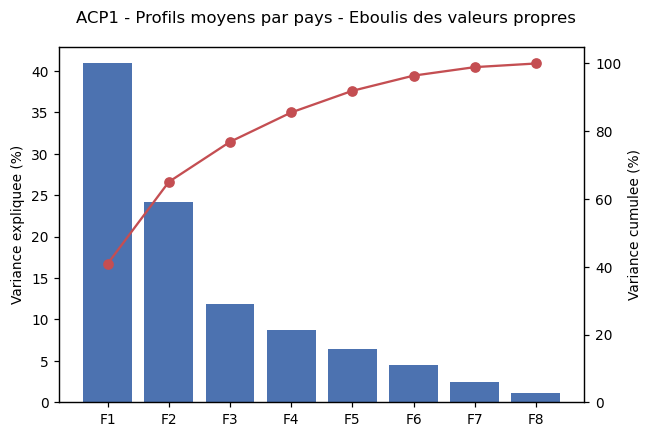

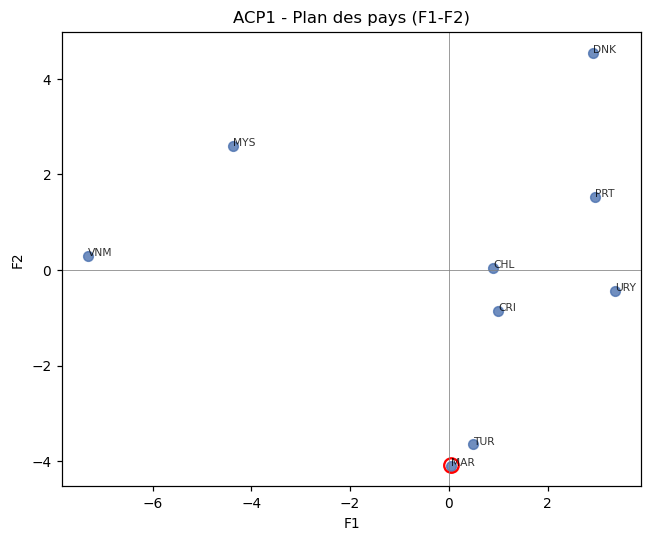

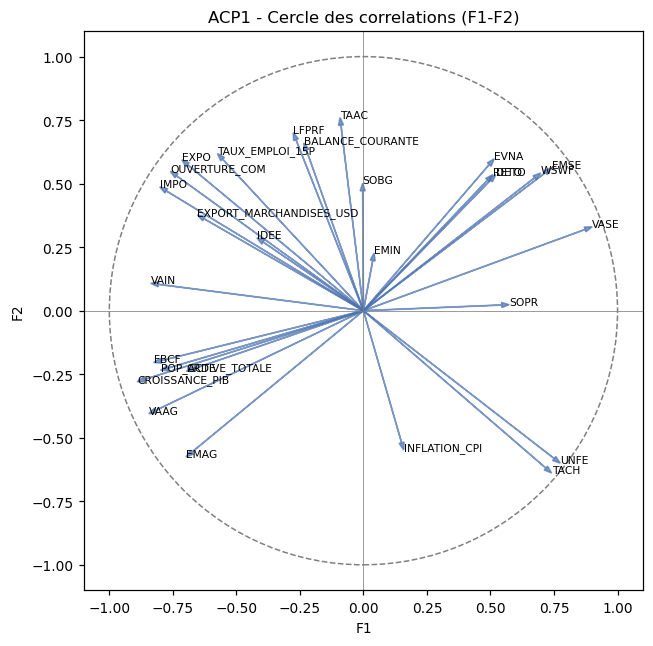

In [15]:
figures_dir = Path(cfg["paths"]["outputs_figures_dir"])
display(Image(filename=str(figures_dir / "acp1_eboulis.png")))
display(Image(filename=str(figures_dir / "acp1_individus_F1F2.png")))
display(Image(filename=str(figures_dir / "acp1_cercle_correlations.png")))


**Interpretation economique (statut : evalue, non valide par un tiers
metier a ce stade).**
- **F1 (~41% de variance)** oppose les economies tres ouvertes/exportatrices
  (Viet Nam, Malaisie, F1 tres negatif, associees a EXPO/IMPO/OUVERTURE_COM
  eleves) aux economies moins tournees vers l export sur cette periode.
- **F2 (~24% de variance)** oppose un pole developpement institutionnel
  (Danemark, Portugal : esperance de vie, recettes/depenses publiques,
  emploi de services eleves) a un pole chomage eleve (Maroc, Turquie :
  TACH et UNFE tres charges negativement).
- **Le Maroc** se situe pres de la moyenne sur F1 (structure d ouverture
  proche de la moyenne de l echantillon) mais tres charge negativement sur
  F2, aux cotes de la Turquie : lecture coherente avec un taux de chomage
  structurellement eleve sur la periode, pas une lecture de retard de
  developpement au sens large (F1 ne le place pas en position extreme).
- Un deplacement dans ce plan ne demontre pas un progres : F2 est domine par
  le chomage, une baisse du chomage deplacerait le Maroc vers le haut sans
  que cela resume a soi seul la trajectoire de developpement.

In [16]:
sens_start, sens_end = cfg["scope"]["sensitivity_common_window"]
acp1_sens_result, _, _ = pca_profiles.run_acp1(work_df, sens_start, sens_end)
display(acp1_sens_result.eigenvalues)


,composante,valeur_propre,variance_expliquee_pct,variance_cumulee_pct
0,F1,13.099329,41.585173,41.585173
1,F2,7.694253,24.426199,66.011372
2,F3,3.583092,11.374896,77.386268
3,F4,2.901980,9.212635,86.598903
4,F5,1.606681,5.100573,91.699476
5,F6,1.519970,4.825302,96.524778
6,F7,0.745656,2.367162,98.891940
7,F8,0.349039,1.108060,100.000000


**Sensibilite (fenetre commune complete).** Recalculee sur la fenetre
sans aucune lacune, la structure de variance expliquee reste proche de celle
de la fenetre 1991-2024 complete (cf. table ci-dessus vs section
precedente) : la conclusion n est pas un artefact des donnees manquantes en
debut de periode.

In [17]:
loco_results = pca_profiles.run_acp1_leave_one_country_out(work_df, year_start, year_end)
loco_rows = [{
    "pays_exclu": c,
    "variance_F1_pct": r.eigenvalues.iloc[0]["variance_expliquee_pct"],
    "variance_F2_pct": r.eigenvalues.iloc[1]["variance_expliquee_pct"],
} for c, r in loco_results.items()]
display(pd.DataFrame(loco_rows))


,pays_exclu,variance_F1_pct,variance_F2_pct
0,CHL,42.005930,25.281962
1,CRI,42.795860,25.071447
2,DNK,44.148797,19.292080
3,MAR,45.688545,20.603575
4,MYS,42.570616,26.657019
5,PRT,41.678195,25.532006
6,TUR,44.166758,22.190366
7,URY,40.128061,25.722795
8,VNM,39.627654,30.024272


**Sensibilite (leave-one-country-out).** La part de variance expliquee
par F1 et F2 reste dans une fourchette raisonnable (F1 : 40-46% ; F2 :
19-30%) quel que soit le pays retire. Le retrait du Viet Nam reduit le plus
F1 (son eloignement pilote une partie de cet axe) ; le retrait du Danemark
reduit le plus F2. Avec 9 pays, cette analyse reste exploratoire (rang
centre maximal = 8) : ces resultats orientent la lecture, ils ne la
valident pas au sens statistique strict.

## 4. ACP2 - Trajectoires annuelles (1991-2024, cas complets)

In [18]:
acp2_result, acp2_scores_flat, acp2_incomplete = pca_trajectories.run_acp2(work_df, year_start, year_end)
print(f"Etats complets utilises : {acp2_result.n_obs} / exclus (incomplets) : {len(acp2_incomplete)}")
display(acp2_result.eigenvalues.head(10))


Etats complets utilises : 278 / exclus (incomplets) : 28


,composante,valeur_propre,variance_expliquee_pct,variance_cumulee_pct
0,F1,8.898045,31.664421,31.664421
1,F2,5.998943,21.347728,53.012149
2,F3,2.710968,9.647201,62.659350
3,F4,2.135976,7.601043,70.260393
4,F5,1.821844,6.483179,76.743573
5,F6,1.504140,5.352604,82.096177
6,F7,1.105648,3.934539,86.030715
7,F8,0.870805,3.098831,89.129546
8,F9,0.638452,2.271982,91.401528
9,F10,0.555637,1.977280,93.378809


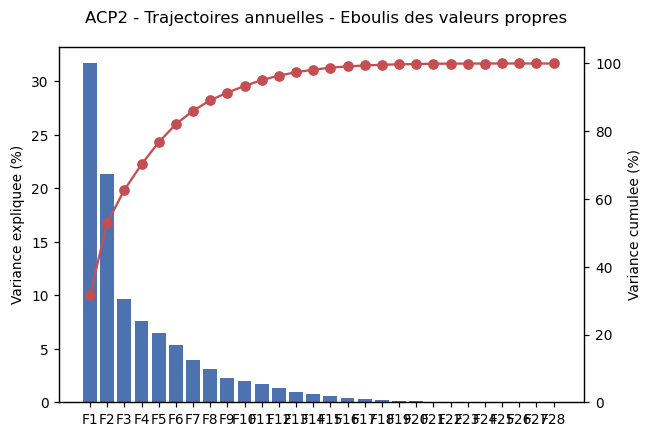

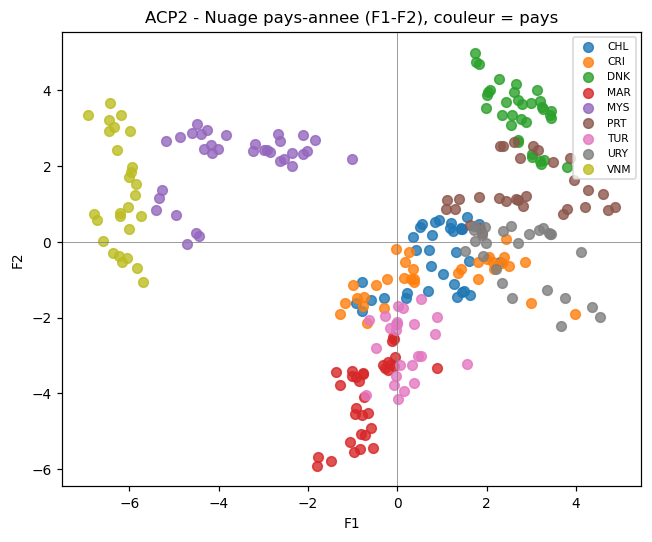

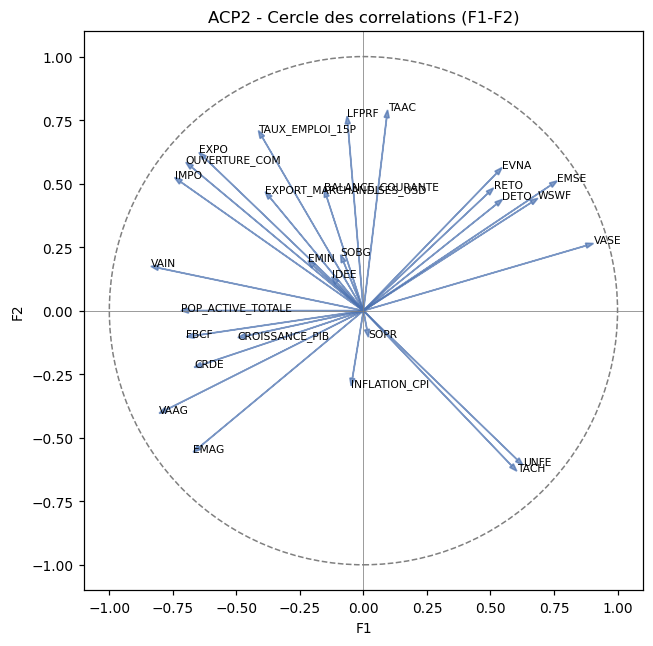

In [19]:
display(Image(filename=str(figures_dir / "acp2_eboulis.png")))
display(Image(filename=str(figures_dir / "acp2_individus_F1F2_par_pays.png")))
display(Image(filename=str(figures_dir / "acp2_cercle_correlations.png")))


**Lecture.** F1 (~32%) et F2 (~21%) reproduisent une structure tres
proche de celle de l ACP1 (openness vs chomage/institutions), ce qui est
rassurant : la structure n est pas un artefact du seul calcul de moyennes.
Le nuage pays-annee forme des paquets bien separes par pays, signe que la
plus grande partie de la variance est entre pays (structurelle) plutot
qu intra-pays au fil du temps (conjoncturelle) sur cette periode.

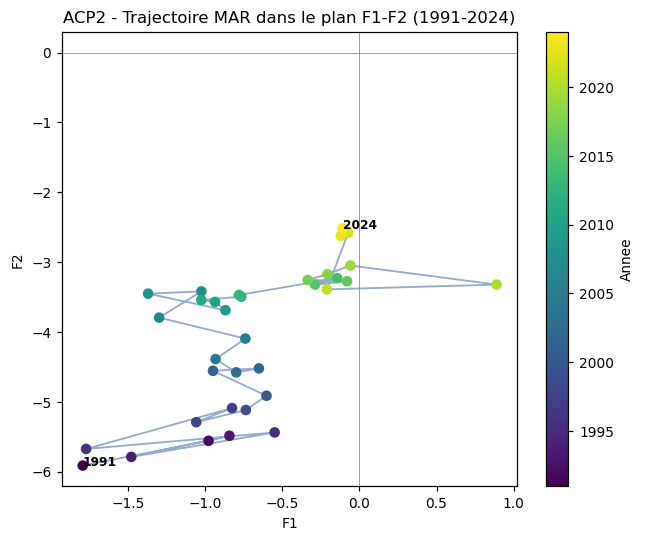

In [20]:
display(Image(filename=str(figures_dir / "acp2_trajectoire_MAR.png")))


**Trajectoire du Maroc (1991-2024).** Le point 1991 se situe tres bas
sur F2 (chomage eleve) et remonte progressivement vers -2.5/-3 en 2024, sans
sortir du quadrant chomage eleve. Sur F1, la trajectoire reste proche de
zero, sans tendance nette vers l ouverture extreme observee pour le Viet
Nam ou la Malaisie. Statut : evalue, non concluant sur la vitesse de
convergence : cette lecture descriptive ne mesure ni la significativite
ni la causalite d une evolution.

## 5. Typologie des pays (K-means vs CAH, k=2 et k=3)

In [21]:
k_values = cfg["clustering"]["k_values"]
seed = cfg["clustering"]["random_state"]
n_init = cfg["clustering"]["n_init"]

comp_cols_acp1 = [c for c in acp1_scores.columns if c.startswith("F")][:2]
acp1_scores_indexed = acp1_scores.set_index("country_iso3")
cluster_acp1 = clustering.cluster_comparison(acp1_scores_indexed, comp_cols_acp1, k_values, seed, n_init)
summary_acp1 = clustering.summarize_cluster_comparison(cluster_acp1, "ACP1_profils_pays_F1F2")
display(summary_acp1)


,espace,k,silhouette_kmeans,silhouette_hierarchical,ari_kmeans_vs_hierarchical,stabilite_ari_moyen_kmeans,effectifs_kmeans,effectifs_hierarchical
0,ACP1_profils_pays_F1F2,2,0.522161,0.522161,1.0,1.0,"{0: 7, 1: 2}","{1: 2, 2: 7}"
1,ACP1_profils_pays_F1F2,3,0.502800,0.502800,1.0,1.0,"{0: 5, 1: 2, 2: 2}","{1: 2, 2: 2, 3: 5}"


In [22]:
for k, res in cluster_acp1.items():
    print(f"--- k={k} ---")
    display(res["assignments"])


--- k=2 ---


,kmeans_cluster,hierarchical_cluster
country_iso3,,
CHL,0,2
CRI,0,2
DNK,0,2
MAR,0,2
MYS,1,1
PRT,0,2
TUR,0,2
URY,0,2
VNM,1,1


--- k=3 ---


,kmeans_cluster,hierarchical_cluster
country_iso3,,
CHL,0,3
CRI,0,3
DNK,0,3
MAR,2,2
MYS,1,1
PRT,0,3
TUR,2,2
URY,0,3
VNM,1,1


**Interpretation (statut : evalue, non impose a priori).**
- **k=2** separe {Malaisie, Viet Nam} du reste (7 pays) : partition dominee
  par l axe d ouverture (F1). Silhouette ~0.52, accord parfait K-means/CAH,
  stabilite parfaite sur 20 tirages de graines.
- **k=3** isole {Maroc, Turquie} comme groupe distinct de {Chili, Costa
  Rica, Danemark, Portugal, Uruguay} et de {Malaisie, Viet Nam}. Silhouette
  ~0.50, meme niveau d accord et de stabilite.
- **Le Maroc ne se regroupe pas avec le Viet Nam ni le Costa Rica** (les
  deux benchmarks principaux retenus par la grille de selection du
  cadrage, Ch. 3), mais avec la Turquie, sur la base du seul profil moyen
  des 28 indicateurs de cette etape. Ceci ne remet pas en cause la
  selection des pays comparateurs du cadrage (fondee sur d autres criteres :
  niveau initial de developpement, structure productive, qualite
  institutionnelle, disponibilite des donnees - voir Ch. 3.2) : cela montre
  seulement qu une proximite dans cet espace ACP purement descriptif ne
  coincide pas automatiquement avec le score de comparabilite du cadrage.
  Une proximite de cluster ne demontre pas la transferabilite d un
  benchmark.

In [23]:
acp2_comp_cols = [c for c in acp2_scores_flat.columns if c.startswith("F")][:2]
acp2_country_centroids = acp2_scores_flat.groupby("country_iso3")[acp2_comp_cols].mean()
cluster_acp2 = clustering.cluster_comparison(acp2_country_centroids, acp2_comp_cols, k_values, seed, n_init)
summary_acp2 = clustering.summarize_cluster_comparison(cluster_acp2, "ACP2_centroides_trajectoires_F1F2")
display(summary_acp2)
for k, res in cluster_acp2.items():
    print(f"--- k={k} ---")
    display(res["assignments"])


,espace,k,silhouette_kmeans,silhouette_hierarchical,ari_kmeans_vs_hierarchical,stabilite_ari_moyen_kmeans,effectifs_kmeans,effectifs_hierarchical
0,ACP2_centroides_trajectoires_F1F2,2,0.529079,0.529079,1.000000,1.0,"{0: 7, 1: 2}","{1: 2, 2: 7}"
1,ACP2_centroides_trajectoires_F1F2,3,0.462562,0.481352,0.347826,1.0,"{0: 4, 1: 2, 2: 3}","{1: 2, 2: 2, 3: 5}"


--- k=2 ---


,kmeans_cluster,hierarchical_cluster
country_iso3,,
CHL,0,2
CRI,0,2
DNK,0,2
MAR,0,2
MYS,1,1
PRT,0,2
TUR,0,2
URY,0,2
VNM,1,1


--- k=3 ---


,kmeans_cluster,hierarchical_cluster
country_iso3,,
CHL,0,3
CRI,0,3
DNK,2,3
MAR,0,2
MYS,1,1
PRT,2,3
TUR,0,2
URY,2,3
VNM,1,1


**Recoupement avec l ACP2.** A k=2, la typologie issue des centroides
de trajectoire (ACP2) reproduit celle de l ACP1. A k=3, K-means et CAH
divergent legerement sur le rattachement de {Chili, Costa Rica} : ce
desaccord (ARI < 1 a k=3 pour cet espace, voir table ci-dessus) est signale
comme moins robuste que la partition k=3 de l ACP1, ou l accord etait
parfait. Statut : evalue, non concluant sur le nombre de classes
correct - 2 et 3 sont deux lectures valides a des granularites
differentes, aucune n est imposee comme la verite.

## 6. Bilan de l etape 1

Voir `docs/AUDIT_ET_ACP_ETAPE1.md` pour la synthese complete redigee, et
`docs/SUIVI_MODELISATION.md` pour l etat d avancement et les decisions
ouvertes avant le passage a l etape 2.